# X-ray luminosity light curve

Unabsorbed 0.3-8 keV X-ray luminosity vs. phase for the 3 unique SN 2018ivc X-ray
epochs, using each epoch's adopted best-fit model (per `xray_epoch_spec_models.xlsx`
and `figure_notebooks/xray_spectra_best_model_by_epoch.ipynb`) and the flux/luminosity
values from Step 5 (`CLAUDE_xray_SOP.md`, `data/Chandra/spectral_fitting/fits/
xray_flux_luminosity.csv`).

Distance: 10.72 Mpc (Cepheid, arXiv:2602.22407 -- see Step 5 for why not the naive
Hubble-flow distance). Error bars are flux-statistical only (from `sample_flux`'s
parameter-covariance Monte Carlo, 1-sigma); the additional +/-9.7% distance
systematic is not included in the plotted error bars (applies equally, as a global
scale factor, to all 3 points).

**Color: each epoch's point uses its position in the single project-wide viridis
epoch list** (`CLAUDE_plotting.md`), same mapping as every other epoch-colored
figure in this project (the X-ray spectral fit comparison figures, the radio SEDs).
Log-log axes per the project's general light-curve/SED formatting convention.

This is data only -- no CSM-interaction model curve yet (that's Step 6,
`redback-csm`, not started). Run under the `18ivc_clean` kernel.

In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))

import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import functions

functions.set_plot_style()

FLUX_LUM_CSV = "../data/Chandra/spectral_fitting/fits/xray_flux_luminosity.csv"

# Position of each X-ray epoch in the single project-wide viridis epoch list
# (CLAUDE_plotting.md "Epoch -> viridis color (SEDs)", x = linspace(1,0,11)).
EPOCH_VIRIDIS_X = {
    "20306": 0.900,
    "29071_29072": 0.400,
    "31211_31996": 0.100,
}
EPOCH_LABELS = {
    "20306": "20306",
    "29071_29072": "29071+29072",
    "31211_31996": "31211+31996",
}

cmap = mpl.colormaps["viridis"]
epoch_colors = {k: cmap(x) for k, x in EPOCH_VIRIDIS_X.items()}

df = pd.read_csv(FLUX_LUM_CSV, dtype={"epoch": str}).set_index("epoch")


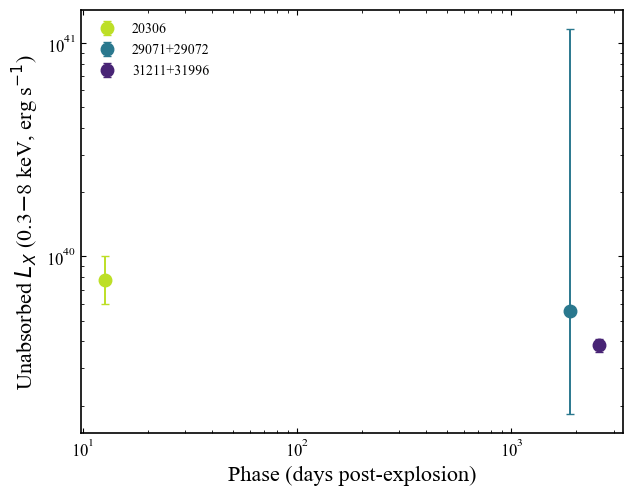

In [2]:
fig, ax = plt.subplots(figsize=(7, 5.5))

for epoch_key in ["20306", "29071_29072", "31211_31996"]:
    row = df.loc[epoch_key]
    ax.errorbar(
        row["phase_days"], row["luminosity_erg_s"],
        yerr=[[row["luminosity_erg_s_errlo"]], [row["luminosity_erg_s_errhi"]]],
        fmt="o", ms=9, capsize=3, lw=1.4, elinewidth=1.4,
        color=epoch_colors[epoch_key], zorder=3,
        label=EPOCH_LABELS[epoch_key],
    )

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Phase (days post-explosion)")
ax.set_ylabel(r"Unabsorbed $L_X$ (0.3$-$8 keV, erg s$^{-1}$)")
ax.legend(fontsize=10, frameon=False, loc="best")

fig.savefig("../figures/xray_luminosity_light_curve.png", dpi=400, bbox_inches="tight")
fig.savefig("../figures/xray_luminosity_light_curve.pdf", bbox_inches="tight")
plt.show()
